In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# -----------------------------
# Step 1. Load simulation results from the LATEST chunk
# -----------------------------
script_dir = os.getcwd()
parent_dir = os.path.dirname(script_dir)

# Find all uncensored survival result files
pattern = os.path.join(parent_dir, 'out', 'FineGridEval_*_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl')
result_files = sorted(glob.glob(pattern))

if len(result_files) == 0:
    raise FileNotFoundError(f"No result files found matching pattern: {pattern}")

# The chunk files are cumulative (chunk_10 ⊂ chunk_20 ⊂ chunk_30, etc.)
# So we only load the LATEST (largest chunk number) to avoid duplicates
latest_file = result_files[-1]
chunk_num = os.path.basename(latest_file).split('_')[1]

print(f"Available chunk files: {[os.path.basename(f) for f in result_files]}")
print(f"Loading LATEST chunk: {os.path.basename(latest_file)} (chunk {chunk_num})")

with open(latest_file, 'rb') as f:
    survival_dfs = pickle.load(f)

print(f"Loaded {len(survival_dfs)} cumulative simulations from chunk {chunk_num}")

# -----------------------------
# Step 2. Combine the simulation rounds
# -----------------------------
df_all = pd.concat(survival_dfs, keys=range(len(survival_dfs)), names=['sim_run'])
df_all = df_all.reset_index(level='sim_run').reset_index(drop=True)

print(f"\nCombined dataset shape: {df_all.shape}")
print(f"Number of unique grid points: {df_all[['T1', 'T2']].drop_duplicates().shape[0]}")
print(f"Number of simulation runs: {df_all['sim_run'].nunique()}")

# -----------------------------
# Step 3. Summarize results over simulation runs
# -----------------------------
grouped = df_all.groupby(['T1', 'T2'])

summary_list = []
methods = ['Initial_1_S', 'Final_5_S','NPMLE_Targeted_S']
for (T1_val, T2_val), group in grouped:
    true_val = group['true_survival'].iloc[0]
    summary = {'T1': T1_val, 'T2': T2_val, 'true_survival': true_val}
    for col in methods:
        fitted_vals = group[col].values
        mean_fitted = np.mean(fitted_vals)
        bias = mean_fitted - true_val
        mse = np.mean((fitted_vals - true_val)**2)
        std = np.std(fitted_vals)
        lower_nom = mean_fitted - 1.96 * std
        upper_nom = mean_fitted + 1.96 * std
        coverage = np.mean((true_val >= (fitted_vals - 1.96 * std)) & (true_val <= (fitted_vals + 1.96 * std)))
        
        summary[f'{col}_mean'] = mean_fitted
        summary[f'{col}_bias'] = bias
        summary[f'{col}_mse'] = mse
        summary[f'{col}_std'] = std
        summary[f'{col}_lower'] = lower_nom
        summary[f'{col}_upper'] = upper_nom
        summary[f'{col}_coverage'] = coverage
    summary_list.append(summary)

df_summary = pd.DataFrame(summary_list)
print(f"\nSummary statistics computed for {len(df_summary)} grid points")
print(df_summary.head())

Available chunk files: ['FineGridEval_10_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_20_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_30_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_40_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl']
Loading LATEST chunk: FineGridEval_40_TargetFromInitial_NPMLE_uncensored_survival_results_TargetingGRID0.1_nSamples500.pkl (chunk 40)
Loaded 40 cumulative simulations from chunk 40

Combined dataset shape: (1600000, 13)
Number of unique grid points: 40000
Number of simulation runs: 40

Summary statistics computed for 40000 grid points
    T1        T2  true_survival  Initial_1_S_mean  Initial_1_S_bias  \
0  0.0  0.000000       0.999245          0.997545         -0.001701   
1  0.0  0.005025       0.998452          0.996304         -0.002147   
2  0.0  0.

In [2]:
df_summary.shape

(40000, 24)

In [3]:
# Print overall summary statistics (averaged across the grid) for each method.
for col in methods:
    overall_abs_bias = df_summary[f'{col}_bias'].abs().mean()
    overall_std = df_summary[f'{col}_std'].mean()
    overall_mse = df_summary[f'{col}_mse'].mean()
    overall_cov = df_summary[f'{col}_coverage'].median()
    print(f"Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")


Method Initial_1_S: Overall abs bias = 0.0027, Overall std = 0.0112, Overall MSE = 0.0002, Overall coverage = 0.950
Method Final_5_S: Overall abs bias = 0.0019, Overall std = 0.0111, Overall MSE = 0.0002, Overall coverage = 0.950
Method NPMLE_Targeted_S: Overall abs bias = 0.0047, Overall std = 0.0134, Overall MSE = 0.0003, Overall coverage = 0.925


In [4]:
# Define the target values and the list of targeting pairs
target_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
targeting_pairs = [(t1, t2) for t1 in target_vals for t2 in target_vals]

# Since the evaluation grid is fine (200x200), we need to find the nearest grid points
# to the target values instead of exact matching
def find_nearest_indices(df, target_vals, tolerance=0.01):
    """Find rows where T1 and T2 are within tolerance of target values"""
    mask = pd.Series(False, index=df.index)
    for t1 in target_vals:
        for t2 in target_vals:
            mask |= ((df['T1'] - t1).abs() < tolerance) & ((df['T2'] - t2).abs() < tolerance)
    return mask

df_sub = df_summary[find_nearest_indices(df_summary, target_vals, tolerance=0.01)]

# Now, compute the overall performance metrics on this subgrid for each method
methods = ['Initial_1_S', 'Final_5_S','NPMLE_Targeted_S']

print(f"Filtered {len(df_sub)} grid points near target values (out of {len(df_summary)} total)")
for col in methods:
    overall_abs_bias = df_sub[f'{col}_bias'].abs().mean()
    overall_std = df_sub[f'{col}_std'].mean()
    overall_mse = df_sub[f'{col}_mse'].mean()
    overall_cov = df_sub[f'{col}_coverage'].median()
    print(f"TargetGrid Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")

Filtered 1296 grid points near target values (out of 40000 total)
TargetGrid Method Initial_1_S: Overall abs bias = 0.0028, Overall std = 0.0122, Overall MSE = 0.0002, Overall coverage = 0.950
TargetGrid Method Final_5_S: Overall abs bias = 0.0021, Overall std = 0.0122, Overall MSE = 0.0002, Overall coverage = 0.950
TargetGrid Method NPMLE_Targeted_S: Overall abs bias = 0.0052, Overall std = 0.0152, Overall MSE = 0.0003, Overall coverage = 0.925


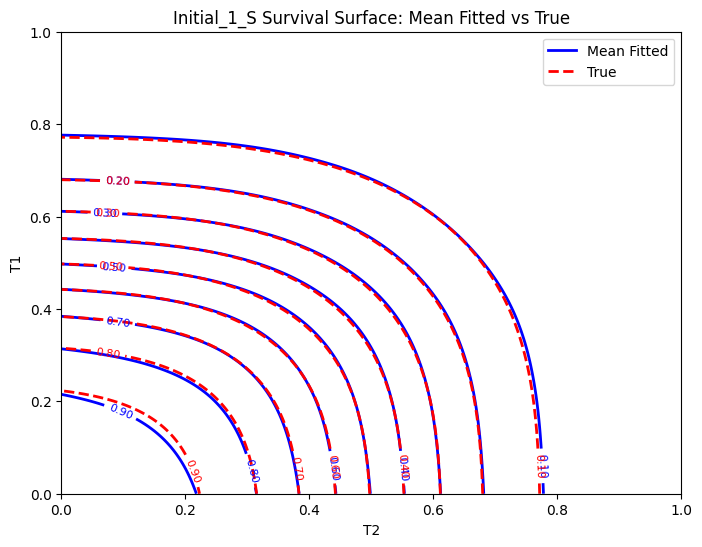

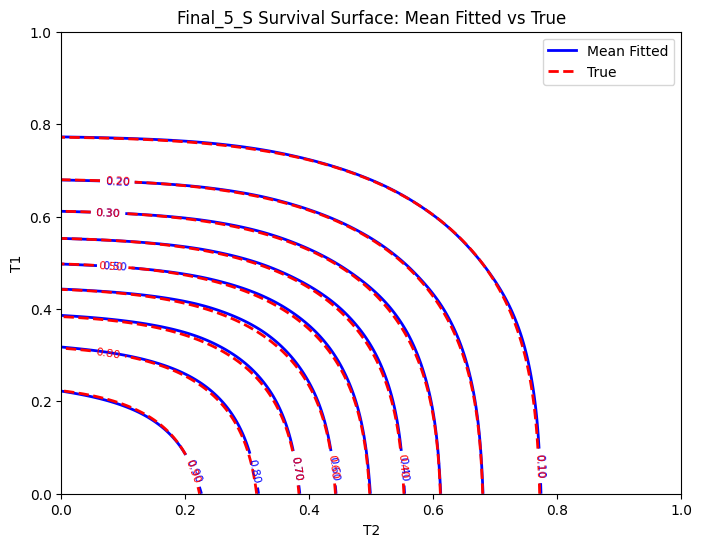

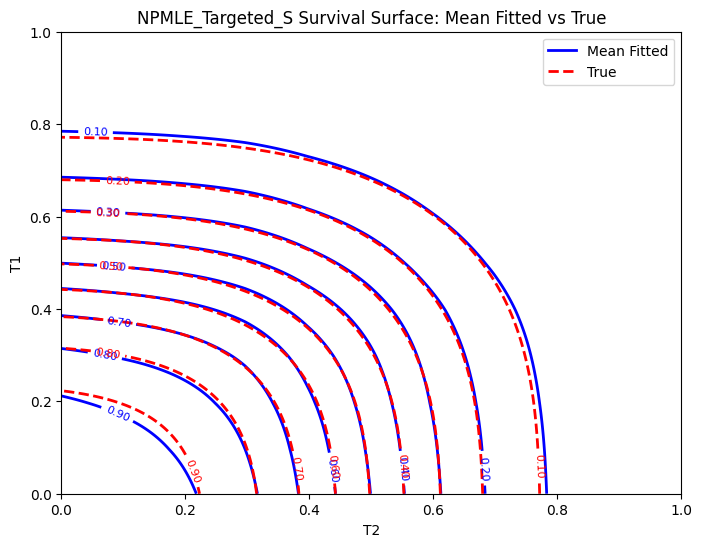

In [5]:
from matplotlib.lines import Line2D

for col in methods:
    # Pivot the summary dataframe for contour plotting.
    pivot_mean = df_summary.pivot(index='T1', columns='T2', values=f'{col}_mean')
    pivot_std = df_summary.pivot(index='T1', columns='T2', values=f'{col}_std')
    pivot_true = df_summary.pivot(index='T1', columns='T2', values='true_survival')
    
    # Create grid arrays.
    T1_vals = pivot_mean.index.values
    T2_vals = pivot_mean.columns.values
    T2_grid, T1_grid = np.meshgrid(T2_vals, T1_vals)
    
    mean_fitted = pivot_mean.values
    lower = mean_fitted - 1.96 * pivot_std.values
    upper = mean_fitted + 1.96 * pivot_std.values

    # Define contour levels for survival probabilities 0.9, 0.8, ..., 0.1.
    levels_surv = np.linspace(0.1, 0.9, 9)
    
    plt.figure(figsize=(8,6))

    # Plot the mean fitted survival surface (blue solid lines).
    cp1 = plt.contour(T2_grid, T1_grid, mean_fitted, levels=levels_surv,
                      colors='blue', linewidths=2, linestyles='-')
    plt.clabel(cp1, inline=True, fontsize=8, fmt='%.2f')

    # Plot the true survival surface (red dashed lines).
    cp2 = plt.contour(T2_grid, T1_grid, pivot_true.values, levels=levels_surv,
                      colors='red', linewidths=2, linestyles='--')
    plt.clabel(cp2, inline=True, fontsize=8, fmt='%.2f')

    # Add a legend using custom legend handles.
    legend_elements = [
         Line2D([0], [0], color='blue', lw=2, linestyle='-', label='Mean Fitted'),
         Line2D([0], [0], color='red', lw=2, linestyle='--', label='True')
    ]
    plt.legend(handles=legend_elements)

    # Include the method name in the title.
    plt.title(f'{col} Survival Surface: Mean Fitted vs True')
    plt.xlabel('T2')
    plt.ylabel('T1')
    plt.show()
